## Network size estimation

N: size of the population (a secret value)

Population: assume a bijection between IDs and integers on 1..N

M: size of the sample, M << N; there is no replacement.

Sort the sample in ascending order: $s_1 < s_2 < ... < s_M$

Compute an estimate, $\hat{N}$, from the sample.


### First approach: German Tank estimation

The German Tank approach uses the maximum observed value, $s_M$, *only.*

The Minimum Variance Unbiased Estimator (MVUE) is:

$\hat{N} = \frac{(M+1)}{M}s_M - 1.$

In [81]:
import numpy as np

import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

In [82]:
def sample_from_population(N: int, M: int) -> np.ndarray:
    '''
    Generate M samples from the integer interval [1, N] without replacement.
    Returns a sorted array of samples.
    '''
    
    samples = np.random.choice(N, size=min(M, N), replace=False) + 1

    return np.sort(samples)

In [83]:
def german_tank_estimate(samples: np.ndarray) -> float:
    """
    Estimate the population size N using the MVUE method.
    """

    s_M = np.max(samples)  # Maximum observed value
    
    m = len(samples)     # Sample size
    
    return ((m + 1)/m)*s_M - 1

In [84]:
def run_experiment(N: int, M: int, num_trials: int = 10, method: str = 'gt'):
    '''
    Run the experiment multiple times and return the estimate(s)
    '''

    estimates = []
    
    for trial in range(num_trials):
        samples = sample_from_population(N, M)

        if method == 'gt':
            estimate = german_tank_estimate(samples)
        elif method == 'rie':
            continue
        elif method == 'se':
            continue
        else:
             estimate = german_tank_estimate(samples)
        
        estimates.append(estimate)
        
        print(f"Trial {trial + 1}: Max sample = {np.max(samples)}, Estimate = {estimate:.2f}")
    
    return estimates

In [ ]:
def visualize_results(estimates, true_N: int, M: int, method: str = 'gt'):
    """
    Create visualizations of the experiment results.
    """
    estimates_array = np.array(estimates)
    
    # Compute statistics
    mean_est = np.mean(estimates_array)
    median_est = np.median(estimates_array)
    std_est = np.std(estimates_array)
    bias = mean_est - true_N
    rmse = np.sqrt(np.mean((estimates_array - true_N) ** 2))
    mae = np.mean(np.abs(estimates_array - true_N))
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    fig.suptitle(f'N={true_N}, M={M}, {len(estimates)} trials')
    
    # Plot 1: Estimates across trials
    ax1 = axes[0, 0]
    trials = np.arange(1, len(estimates) + 1)
    ax1.plot(trials, estimates, 'bo-', label='Estimates', markersize=8)
    ax1.axhline(y=true_N, color='r', linestyle='--', linewidth=2, label=f'True N = {true_N}')
    ax1.axhline(y=mean_est, color='g', linestyle='-.', linewidth=2, label=f'Mean = {mean_est:.2f}')
    ax1.set_xlabel('Trial Number', fontsize=12)
    ax1.set_ylabel('Estimated N', fontsize=12)
    ax1.set_title('Estimates Across Trials', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Histogram of estimates
    ax2 = axes[0, 1]

    ax2.hist(estimates, bins=min(10, len(set(estimates))), edgecolor='black', alpha=0.7, color='skyblue')

    ax2.axvline(x=true_N, color='r', linestyle='--', linewidth=2, label=f'True N = {true_N}')
    ax2.axvline(x=mean_est, color='g', linestyle='-.', linewidth=2, label=f'Mean = {mean_est:.2f}')
    ax2.set_xlabel('Estimated N', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distr. of Estimates', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Error analysis
    ax3 = axes[1, 0]
    errors = estimates_array - true_N
    
    ax3.bar(trials, errors, color=['red' if e < 0 else 'green' for e in errors], alpha=0.7)

    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax3.set_xlabel('Trial Number', fontsize=12)
    ax3.set_ylabel('Error (Estimate - True N)', fontsize=12)
    ax3.set_title('Estimation Error by Trial', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Statistics summary
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    stats_data = [
        ['True N', f'{true_N}'],
        ['Sample Size (M)', f'{M}'],
        ['Number of Trials', f'{len(estimates)}'],
        ['Method', f'{method}'],
        ['', ''],
        ['Mean Estimate', f'{mean_est:.2f}'],
        ['Median Estimate', f'{median_est:.2f}'],
        ['Std Dev', f'{std_est:.2f}'],
        ['Min Estimate', f'{np.min(estimates_array):.2f}'],
        ['Max Estimate', f'{np.max(estimates_array):.2f}'],
        ['', ''],
        ['Bias', f'{bias:.2f}'],
        ['RMSE', f'{rmse:.2f}'],
        ['Mean Absolute Error', f'{mae:.2f}']
    ]
    
    table = ax4.table(cellText=stats_data, cellLoc='left', loc='center',
                     colWidths=[0.6, 0.4])#
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)
    
    # Style the table
    for i in range(len(stats_data)):
        if i in [0, 4, 10]:  # Header rows
            table[(i, 0)].set_facecolor('#4CAF50')
            table[(i, 1)].set_facecolor('#4CAF50')
            table[(i, 0)].set_text_props(weight='bold', color='white')
            table[(i, 1)].set_text_props(weight='bold', color='white')
            
        elif stats_data[i][0] == '':  # Separator rows
            table[(i, 0)].set_facecolor('#f0f0f0')
            table[(i, 1)].set_facecolor('#f0f0f0')
    
    # ax4.set_title('Summary Stats')
    
    plt.tight_layout()
    plt.show()

### Run the Experiment

In [86]:
# Experiment parameters

N = 1000  # True population size

M = 50    # Number of samples per trial

num_trials = 10  # Number of trials

method = 'gt' # or 'rie', 'se' or 'cr'

print(f"{'='*60}")
print(f"True population size (N): {N}")
print(f"Sample size per trial (M): {M}")
print(f"Number of trials: {num_trials}")
print(f"Method: {method}")
print(f"{'='*60}\n")

True population size (N): 1000
Sample size per trial (M): 50
Number of trials: 10
Method: gt



In [87]:
# Run the experiment
estimates = run_experiment(N, M, num_trials, method)

Trial 1: Max sample = 987, Estimate = 1005.74
Trial 2: Max sample = 984, Estimate = 1002.68
Trial 3: Max sample = 995, Estimate = 1013.90
Trial 4: Max sample = 972, Estimate = 990.44
Trial 5: Max sample = 991, Estimate = 1009.82
Trial 6: Max sample = 957, Estimate = 975.14
Trial 7: Max sample = 998, Estimate = 1016.96
Trial 8: Max sample = 978, Estimate = 996.56
Trial 9: Max sample = 987, Estimate = 1005.74
Trial 10: Max sample = 989, Estimate = 1007.78


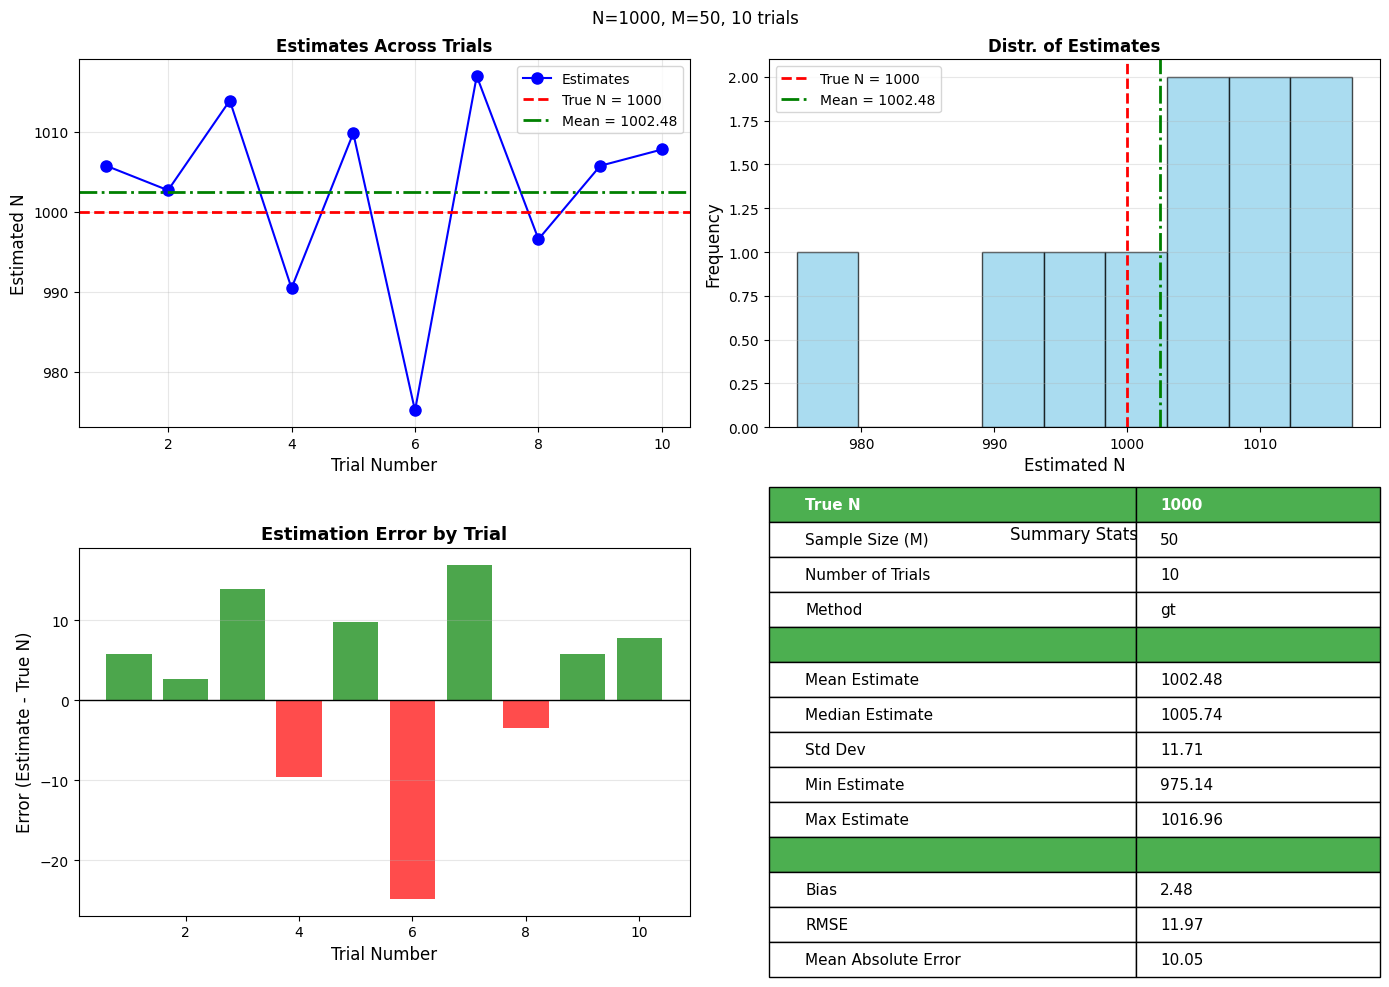

In [88]:
# Visualize results
visualize_results(estimates, N, M, method)